# Duration modeling

We've chosen to model pandemic durations as following a lognormal distribution, i.e. the duration random variable $D$:

$$ln(D) \sim N(\mu, \sigma)$$

One implication of this modeling decision is that duration is rather fat-tailed. This captures evidently plausible outcomes such as HIV/AIDS, but fitting to the data leads to even 200 year+ pandemics receiving substantial probability density. Sensible treatment therefore requires ex post truncation. I currently truncate at ten years, as we have done previously; we'll presumably want to conduct sensitivity analysis to this choice.

I will nonetheless proceed with the lognormal distribution, but we could consider whether alternative distributions might better reflect our views without ad hoc truncation.

We apply the transform 

$$ \sigma = \ln(1 + e^\eta)$$

to conduct MLE estimation in an unconstrained domain.

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import minimize
from scipy.stats import lognorm

from pandemic_model.grad import hess
from pandemic_model.stats.utils import softplus, softplus_inv

In [44]:
# Load actual duration data
final_allrisk_ds = pd.read_csv("../../data/clean/final_allrisk_ds.csv")
duration_data = final_allrisk_ds['duration']

In [45]:
TRUNC_YEARS = 10
rng = np.random.default_rng(24)

In [46]:
def to_phi(theta):
    """θ = (mu, sigma)  →  φ = (mu, eta1)  all in ℝ"""
    mu, sigma = theta
    return np.array([mu, softplus_inv(sigma)])

def from_phi(phi):
    """φ = (ψ, φ₁, φ₂) → θ = (p, ξ, σ)  all valid"""
    mu, eta1 = phi
    return np.array([mu, softplus(eta1)])

# ------------------------------------------------------------------
# 2.  NEGATIVE LOG-LIKELIHOOD
# ------------------------------------------------------------------
def nll_phi(phi, data):
    """Negative log-likelihood of exceedances y (>0) given φ=(ψ,φ1,φ2)."""
    mu, sigma = from_phi(phi)
    ll = lognorm.logpdf(data, s=sigma, scale=np.exp(mu)).sum()
    
    return -ll

In [47]:
# ------------------------------------------------------------------
# 3.  MULTI-START MLE
# ------------------------------------------------------------------
def fit_duration(data, start_grid):
    results = []
    for mu, sigma in start_grid:
        phi0 = to_phi((mu, sigma))
        
        # Nelder-Mead optimization
        nelder_mead_opts = {
            'maxiter': 10000,
            'maxfev': 50000,
            'xatol': 1e-4,
            'fatol': 1e-4,
            'adaptive': True
        }
        
        opt = minimize(nll_phi, phi0, args=(data),
                       method='Nelder-Mead', options=nelder_mead_opts)
        
        if not opt.success:
            error_msg = f"Optimization failed: {opt.message}\n"
            error_msg += f"Status: {opt.status}\n"
            error_msg += f"Number of iterations: {opt.nit}\n"
            error_msg += f"Final function value: {opt.fun}\n"
            error_msg += f"Final parameters: {from_phi(opt.x)}"
            raise RuntimeError(error_msg)
            
        # Calculate full Hessian at optimal point
        (est_mu, est_eta1) = opt.x
        est_mu, est_sigma = from_phi(opt.x)
        info = len(data) * np.array([[1, 0], [0, 2]]) * (1 / est_eta1 ** 2)
        cov = np.linalg.inv(info)  # asymptotic covariance
        
        results.append({
            "start":   (mu, sigma),
            "mu":      est_mu,
            "sigma":   est_sigma,
            "opt":     opt,
            "success": opt.success,
            "fun":     opt.fun,
            "hess_inv": cov
        })
        
    df = pd.DataFrame(results)
    best = df.loc[df.fun.idxmin()]
    return df, best


In [48]:
# Create grid of starting points for mu and sigma
duration_mean = duration_data.mean()
duration_median = duration_data.median()

start_grid = [
    (np.log(duration_mean), 0.5),  # Mean-based mu, moderate sigma
    (np.log(duration_mean), 1.0),  # Mean-based mu, larger sigma
    (np.log(duration_median), 0.5),  # Median-based mu, moderate sigma 
    (np.log(duration_median), 1.0),  # Median-based mu, larger sigma
    (np.log(duration_mean) - 0.5, 0.3),  # Lower mu, small sigma
    (np.log(duration_mean) + 0.5, 0.3)   # Higher mu, small sigma
]

# Fit models with different starting points
results_df, best_fit = fit_duration(duration_data, start_grid)

print("\nBest fit:")
print(f"mu: {best_fit.mu:.3f}")
print(f"sigma: {best_fit.sigma:.3f}")
print(f"log-likelihood: {-best_fit.fun:.3f}")
results_df


Best fit:
mu: 1.320
sigma: 1.222
log-likelihood: -17.638


,start,mu,sigma,opt,success,fun,hess_inv
0,"(2.2857779746776643, 0.5)",1.320519,1.221658,"{'fun': 17.637759076076666, 'nit': 48, 'nfev':...",True,17.637759,"[[0.12686684863781228, 0.0], [0.0, 0.063433424..."
1,"(2.2857779746776643, 1.0)",1.320533,1.221638,"{'fun': 17.637759075474406, 'nit': 35, 'nfev':...",True,17.637759,"[[0.1268584021256117, 0.0], [0.0, 0.0634292010..."
2,"(0.9162907318741551, 0.5)",1.320475,1.221623,"{'fun': 17.637759074660924, 'nit': 43, 'nfev':...",True,17.637759,"[[0.12685225834245684, 0.0], [0.0, 0.063426129..."
3,"(0.9162907318741551, 1.0)",1.320500,1.221654,"{'fun': 17.63775907448791, 'nit': 35, 'nfev': ...",True,17.637759,"[[0.12686516860856759, 0.0], [0.0, 0.063432584..."
4,"(1.7857779746776643, 0.3)",1.320449,1.221660,"{'fun': 17.637759080215737, 'nit': 42, 'nfev':...",True,17.637759,"[[0.12686758694269545, 0.0], [0.0, 0.063433793..."
5,"(2.7857779746776643, 0.3)",1.320469,1.221652,"{'fun': 17.637759075753475, 'nit': 45, 'nfev':...",True,17.637759,"[[0.12686399546182567, 0.0], [0.0, 0.063431997..."


In [49]:
best_fit.opt.x

array([1.32049975, 0.87246261])

In [50]:
n_samples = 50_000
best_phi = best_fit.opt.x
best_cov = best_fit.hess_inv

phi_draws = rng.multivariate_normal(best_phi, best_cov, size=n_samples)
theta_draws = np.vstack([from_phi(phi) for phi in phi_draws])
mu_sample, sigma_sample = np.hsplit(theta_draws, 2)

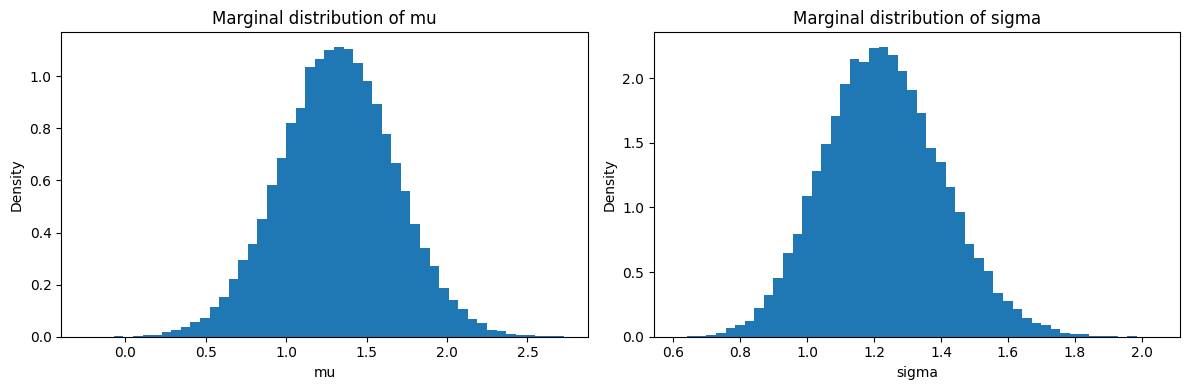

In [51]:
# Plot marginal histograms of mu and sigma
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Plot histogram of mu
ax1.hist(mu_sample, bins=50, density=True)
ax1.set_xlabel('mu')
ax1.set_ylabel('Density')
ax1.set_title('Marginal distribution of mu')

# Plot histogram of sigma 
ax2.hist(sigma_sample, bins=50, density=True)
ax2.set_xlabel('sigma')
ax2.set_ylabel('Density')
ax2.set_title('Marginal distribution of sigma')

plt.tight_layout()
plt.show()

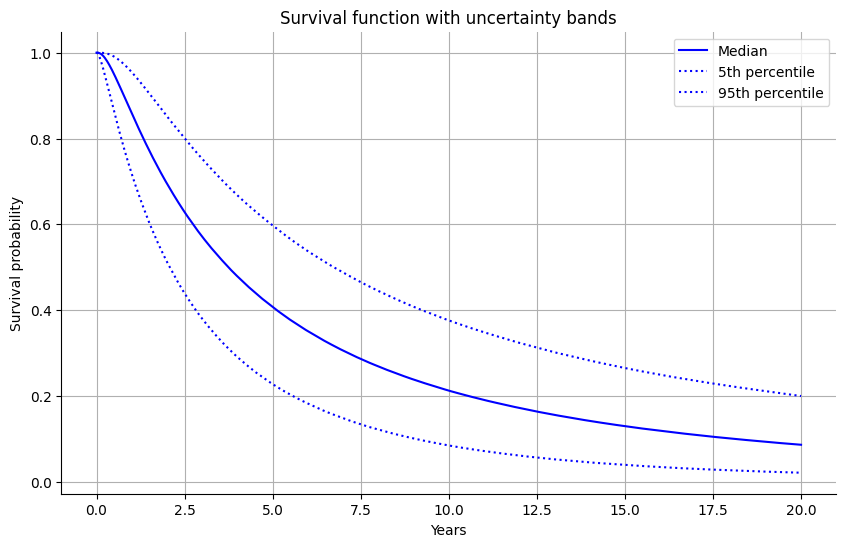

In [ ]:
# Time points for survival function evaluation
t = np.linspace(0, 20, 1000)  # Evaluate up to 20 years

# Calculate survival functions for each sampled mu, sigma pair
t_mat = np.tile(t, (n_samples, 1))  # Shape: (1000, n_samples)
survivals = lognorm.sf(t_mat, s=sigma_sample, scale=np.exp(mu_sample))

# Calculate percentiles across samples at each time point
percentiles = np.percentile(survivals, [5, 50, 95], axis=0)

# Plot the survival functions
plt.figure(figsize=(10, 6))
plt.plot(t, percentiles[1], label='Median', color='blue')
plt.plot(t, percentiles[0], label='5th percentile', color='blue', linestyle=':')
plt.plot(t, percentiles[2], label='95th percentile', color='blue', linestyle=':')

plt.xlabel('Years')
plt.ylabel('Survival probability')
plt.title('Survival function with uncertainty bands')
plt.legend()
plt.grid(True)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

In [53]:
sample_df = pd.DataFrame({'mu': mu_sample.squeeze(), 'sigma': sigma_sample.squeeze(), 'trunc_value': TRUNC_YEARS})
sample_df.to_csv("../../output/duration_distributions/allrisk_base_mu_sigma_samples.csv", index=0)